# Telco Customer Churn Prediction — EDA & Baseline Modeling
**Task 1 · AI/ML Domain** — end-to-end pipeline: cleaning → EDA → preprocessing → model comparison → evaluation.

**Problem:** predict whether a telecom customer will churn (`Churn = Yes`) so the business can target retention offers.
**Type:** binary classification, imbalanced (~26.5% churners).
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns).

**Pipeline design principle — no data leakage:** the train/test split happens *before* any statistic is learned. Imputation medians, outlier fences, scaling parameters and one-hot categories are all fitted on the training set only, inside a scikit-learn `Pipeline`, so cross-validation is leak-free as well.

## 0. Setup
The helper module `churn_utils.py` (feature engineering + an IQR `Winsorizer`) is written here so the notebook runs standalone in Colab/Kaggle. The same file is imported by the Streamlit app, which guarantees the saved model loads identically.

In [1]:
%%writefile churn_utils.py
"""Shared helpers used by both the notebook (training) and the Streamlit app (inference).
Keeping them in one module guarantees the saved pipeline can be unpickled identically."""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

SERVICE_COLS = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "NumServices"]
CATEGORICAL_FEATURES = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
                        "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                        "Contract", "PaperlessBilling", "PaymentMethod"]
RAW_FEATURES = ["gender", "SeniorCitizen", "Partner", "Dependents", "tenure", "PhoneService",
                "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
                "PaperlessBilling", "PaymentMethod", "MonthlyCharges", "TotalCharges"]


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Stateless feature engineering (safe to apply before the train/test split - no leakage,
    because it uses only each row's own values)."""
    df = df.copy()
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)
    # Count of subscribed services (proxy for how embedded the customer is)
    df["NumServices"] = sum((df[c] == "Yes").astype(int) for c in SERVICE_COLS) + \
        (df["InternetService"] != "No").astype(int)
    return df


class Winsorizer(BaseEstimator, TransformerMixin):
    """Caps outliers at IQR fences learned ONLY from the training data (no leakage)."""
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_, self.upper_ = q1 - self.k * iqr, q3 + self.k * iqr
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, names=None):
        return np.asarray(names)

Overwriting churn_utils.py


In [2]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report)
from churn_utils import add_features, Winsorizer, NUMERIC_FEATURES, CATEGORICAL_FEATURES, RAW_FEATURES

sns.set_theme(style="whitegrid", palette="deep"); RANDOM_STATE = 42
os.makedirs("data", exist_ok=True); os.makedirs("models", exist_ok=True); os.makedirs("images", exist_ok=True)
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
PATH = "data/Telco-Customer-Churn.csv"
df = pd.read_csv(PATH if os.path.exists(PATH) else URL)
df.to_csv(PATH, index=False)
print(df.shape); df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Understanding & Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# 'TotalCharges' is stored as text because 11 rows contain a blank string -> coerce to numeric
print("Blank TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nRows with missing TotalCharges (all have tenure = 0, i.e. brand-new customers):")
print(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "Churn"]].head())
print("\nDuplicate rows:", df.duplicated().sum(), "| duplicate customer IDs:", df["customerID"].duplicated().sum())

Blank TotalCharges: 11
Missing values per column:
 TotalCharges    11
dtype: int64

Rows with missing TotalCharges (all have tenure = 0, i.e. brand-new customers):
      customerID  tenure  MonthlyCharges Churn
488   4472-LVYGI       0           52.55    No
753   3115-CZMZD       0           20.25    No
936   5709-LVOEQ       0           80.85    No
1082  4367-NUYAO       0           25.75    No
1340  1371-DWPAZ       0           56.05    No

Duplicate rows: 0 | duplicate customer IDs: 0


**Findings / decisions**
- `TotalCharges` has 11 blank strings, all for customers with `tenure = 0` (they haven't been billed yet). They are real "missing" values rather than errors, so I **impute with the training-set median inside the pipeline** instead of dropping rows (dropping would waste data and the imputer is leak-free).
- No duplicate customers. `customerID` is a pure identifier with no predictive meaning, so it is **dropped**.
- `SeniorCitizen` is 0/1 but semantically categorical, so it's treated as a category.
- "No internet service" / "No phone service" are valid categories (not missing) and kept as-is.

In [5]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df = df.drop(columns="customerID")
df = add_features(df)   # NumServices (stateless -> no leakage)
df[["tenure", "MonthlyCharges", "TotalCharges", "NumServices"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
NumServices,7043.0,4.146244,2.312720,1.00,2.00,4.000,6.0000,9.00


**Feature engineering:** `NumServices` counts the services a customer subscribes to (a proxy for how embedded they are). It uses only a row's own values, so creating it before the split does not leak information. I also tested `TotalCharges / tenure`, but it has ~1.00 correlation with `MonthlyCharges` (see the heatmap in 2.5), so it adds no information and was **dropped**.

## 2. Exploratory Data Analysis

### 2.1 Target distribution

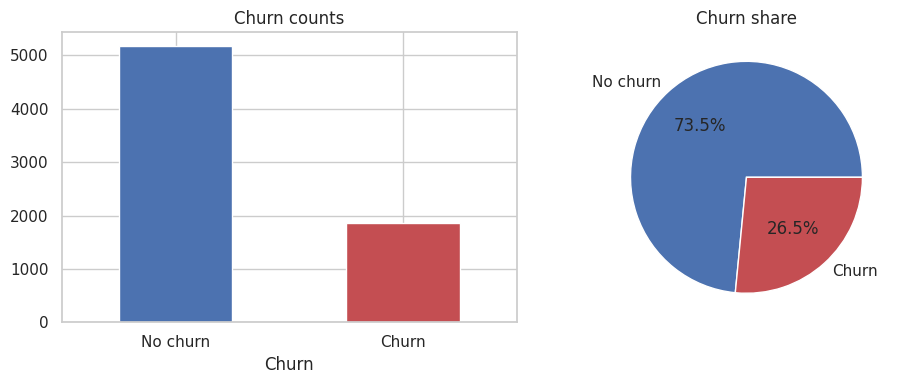

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df["Churn"].value_counts().plot.bar(ax=ax[0], color=["#4C72B0", "#C44E52"]); ax[0].set_xticklabels(["No churn", "Churn"], rotation=0); ax[0].set_title("Churn counts")
df["Churn"].value_counts().plot.pie(ax=ax[1], autopct="%.1f%%", labels=["No churn", "Churn"], colors=["#4C72B0", "#C44E52"]); ax[1].set_ylabel(""); ax[1].set_title("Churn share")
plt.tight_layout(); plt.show()

**Finding:** the classes are imbalanced (~73/27). Accuracy alone would be misleading (a model predicting "no churn" always gets ~73%), so I'll focus on **Recall, F1 and ROC-AUC**, use **stratified splits**, and use `class_weight='balanced'` for the models.

### 2.2 Univariate analysis — numeric features

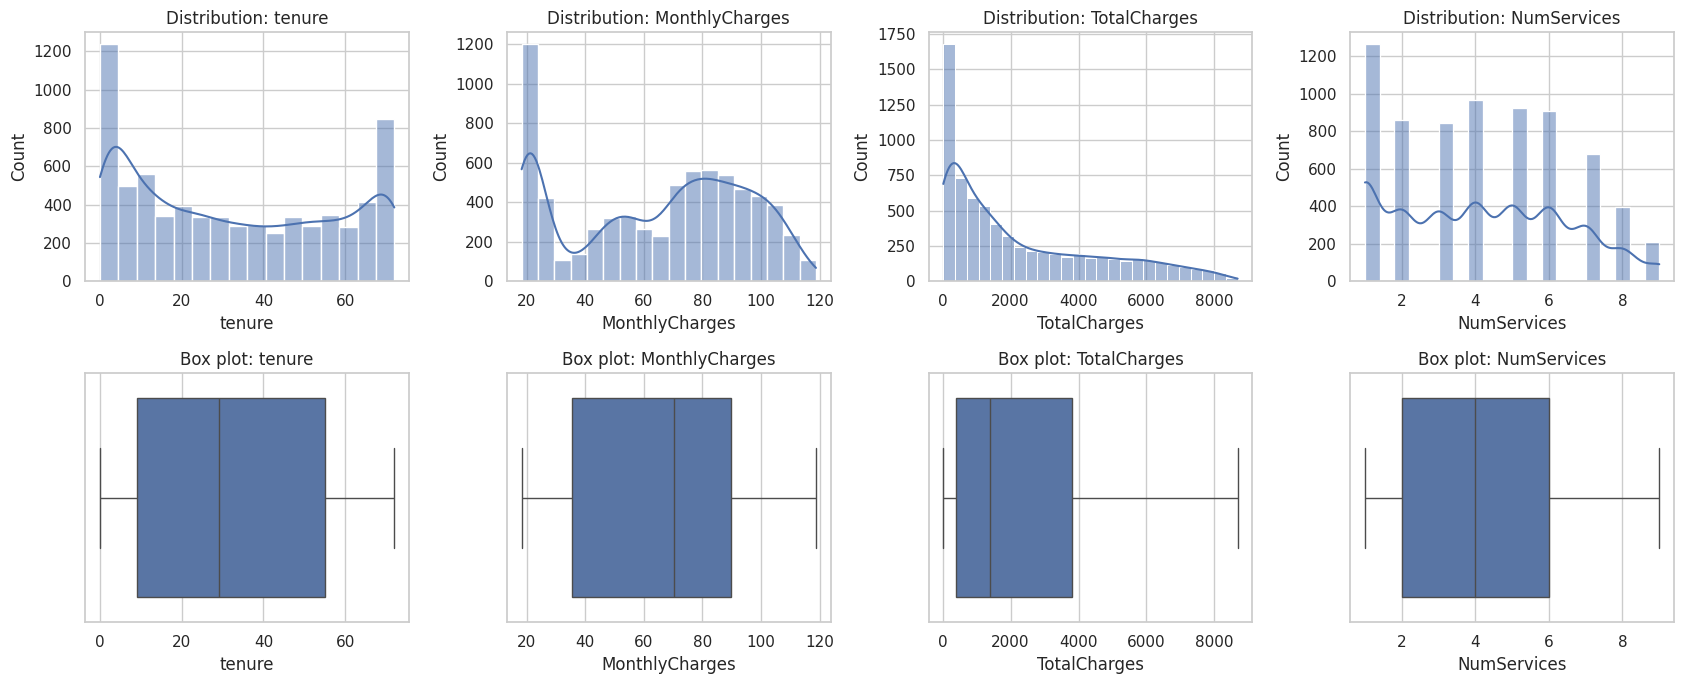

Skewness:
 tenure            0.24
MonthlyCharges   -0.22
TotalCharges      0.96
NumServices       0.22
dtype: float64


In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "NumServices"]
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, ax=axes[0, i]); axes[0, i].set_title(f"Distribution: {c}")
    sns.boxplot(x=df[c], ax=axes[1, i]); axes[1, i].set_title(f"Box plot: {c}")
plt.tight_layout(); plt.show()
print("Skewness:\n", df[num_cols].skew().round(2))

**Findings**
- `tenure` is bimodal: many brand-new customers and many long-term loyal ones.
- `MonthlyCharges` is multi-modal (different plan tiers); `TotalCharges` is right-skewed (it grows with tenure).
- Box plots (and the IQR check below) show **no statistical outliers** in this dataset: every numeric feature is bounded by realistic business limits (tenure ≤ 72 months, charges ≤ ~$119). I therefore delete nothing, but keep an **IQR winsorizer (cap, don't delete)** in the pipeline as a safeguard: it is a no-op here, yet protects the model if the app or future data contains extreme values.

In [8]:
# How many values fall outside the 1.5*IQR fences?
for c in num_cols:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    n = ((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum()
    print(f"{c:20s} outliers: {n:4d} ({n/len(df):.2%})")

tenure               outliers:    0 (0.00%)
MonthlyCharges       outliers:    0 (0.00%)
TotalCharges         outliers:    0 (0.00%)
NumServices          outliers:    0 (0.00%)


### 2.3 Univariate analysis — categorical features

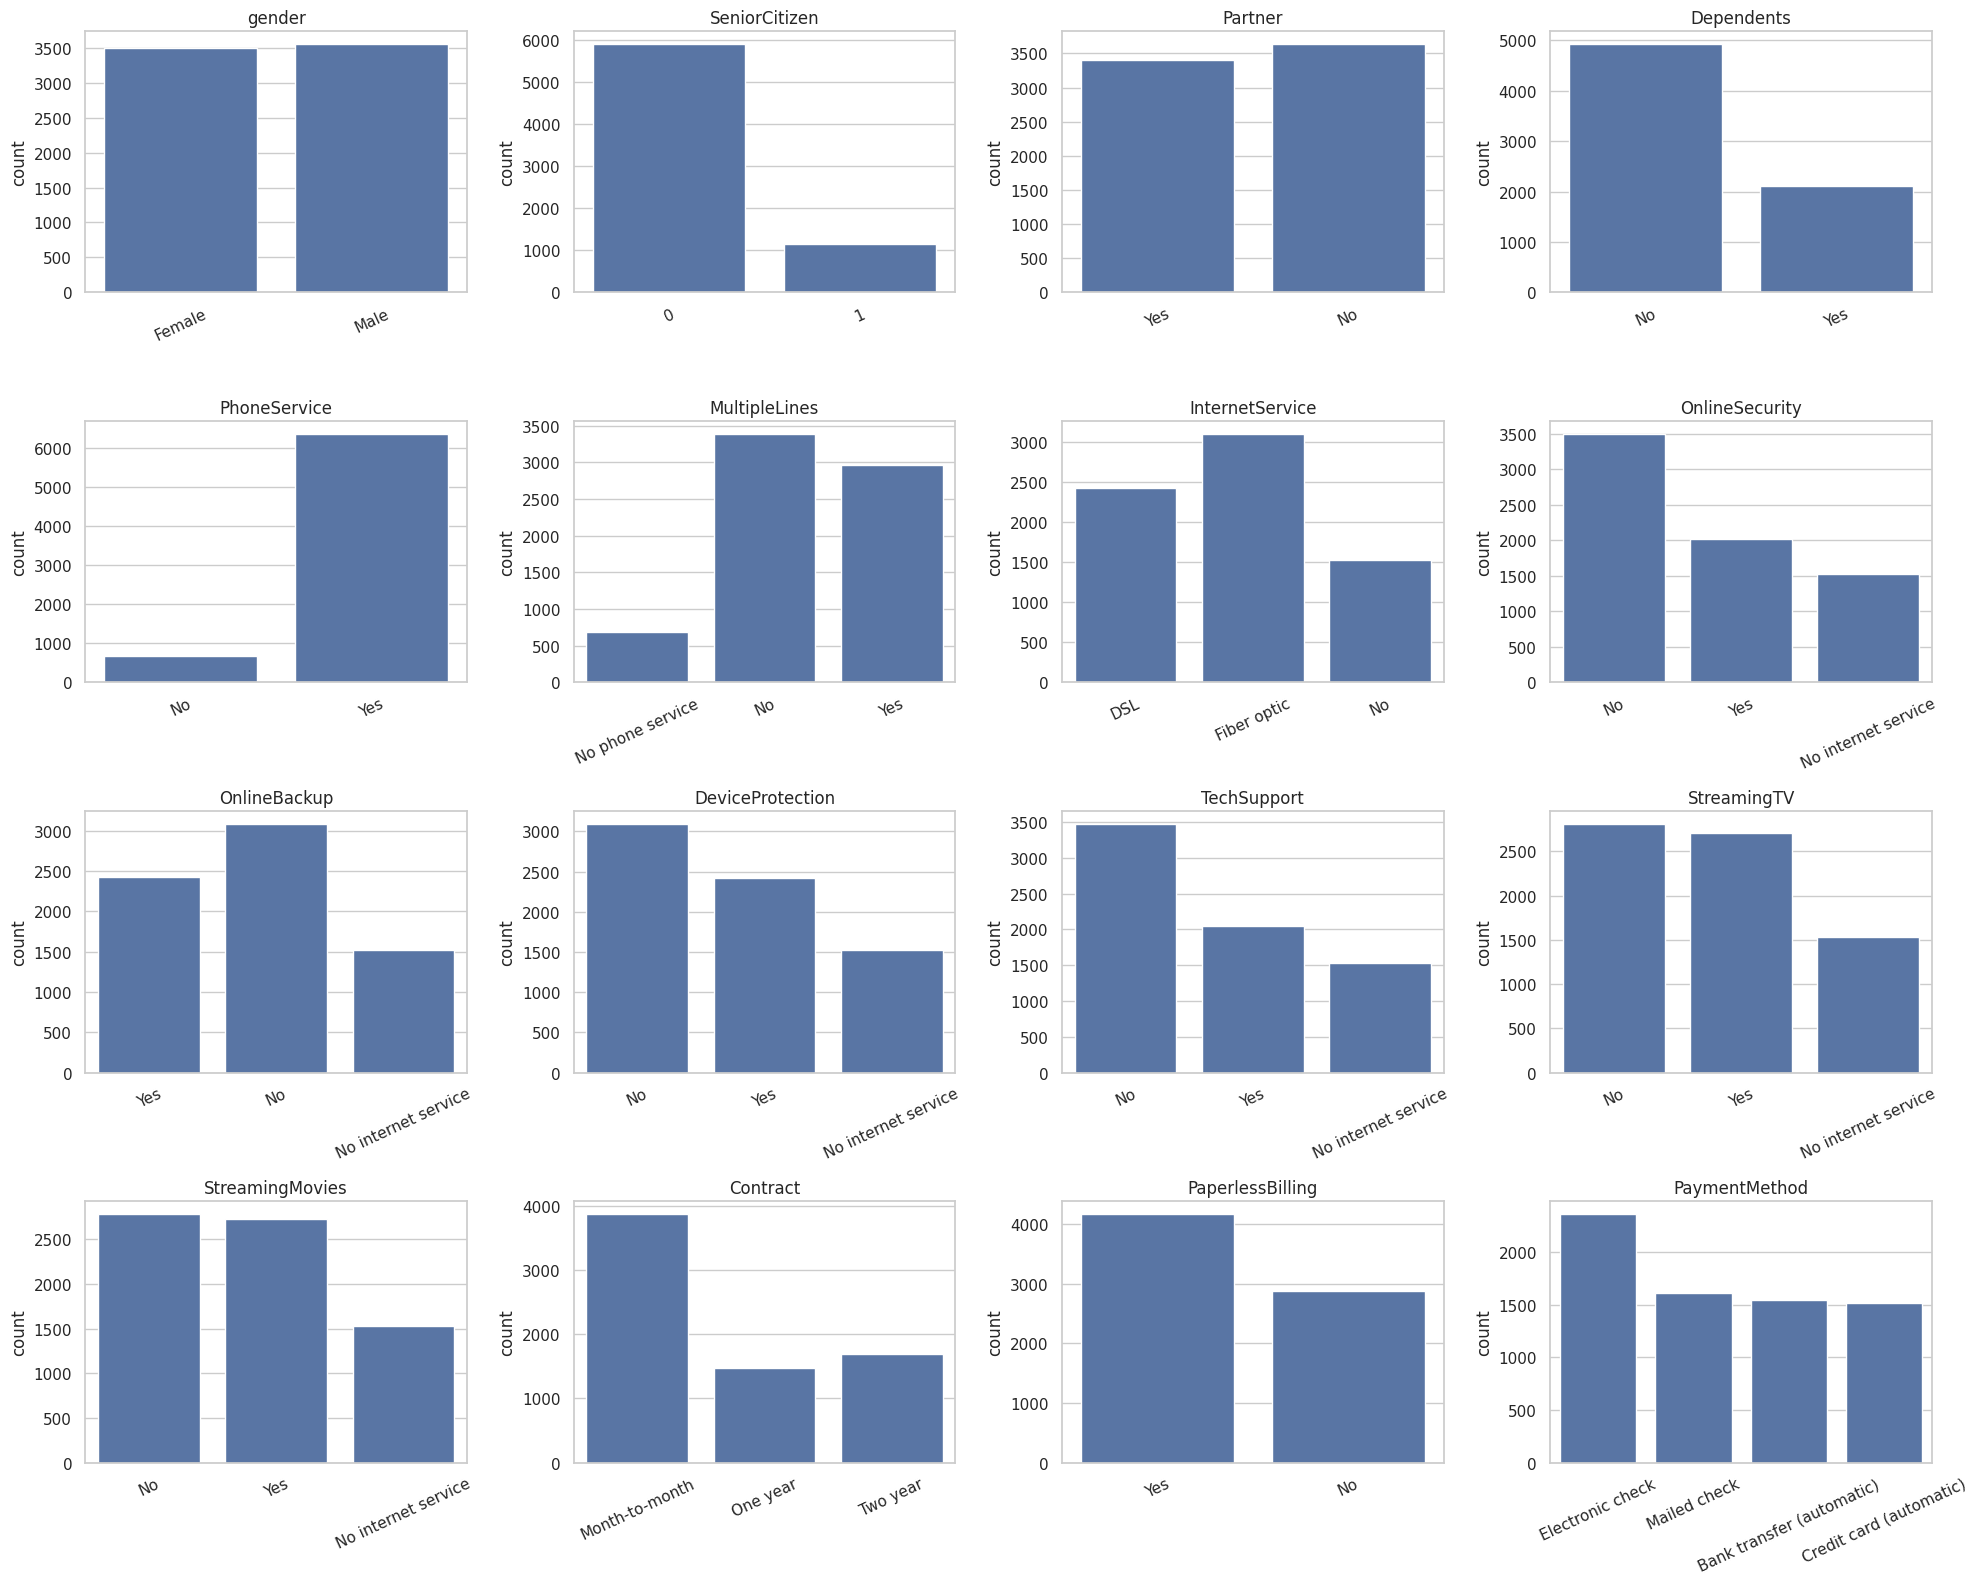

In [9]:
cat_cols = [c for c in CATEGORICAL_FEATURES]
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, c in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=c, ax=ax); ax.set_title(c); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### 2.4 Bivariate analysis — features vs. churn

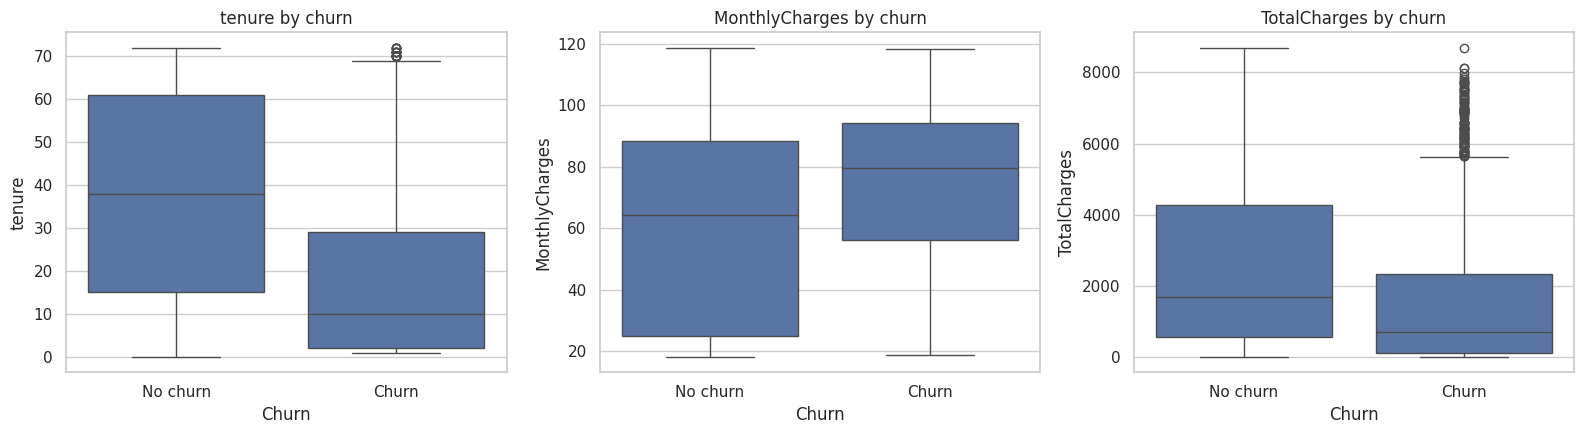

       tenure  MonthlyCharges  TotalCharges  NumServices
Churn                                                   
0        38.0          64.425       1683.60          4.0
1        10.0          79.650        703.55          4.0


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df, x="Churn", y=c, ax=ax); ax.set_xticklabels(["No churn", "Churn"]); ax.set_title(f"{c} by churn")
plt.tight_layout(); plt.show()
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges", "NumServices"]].median())

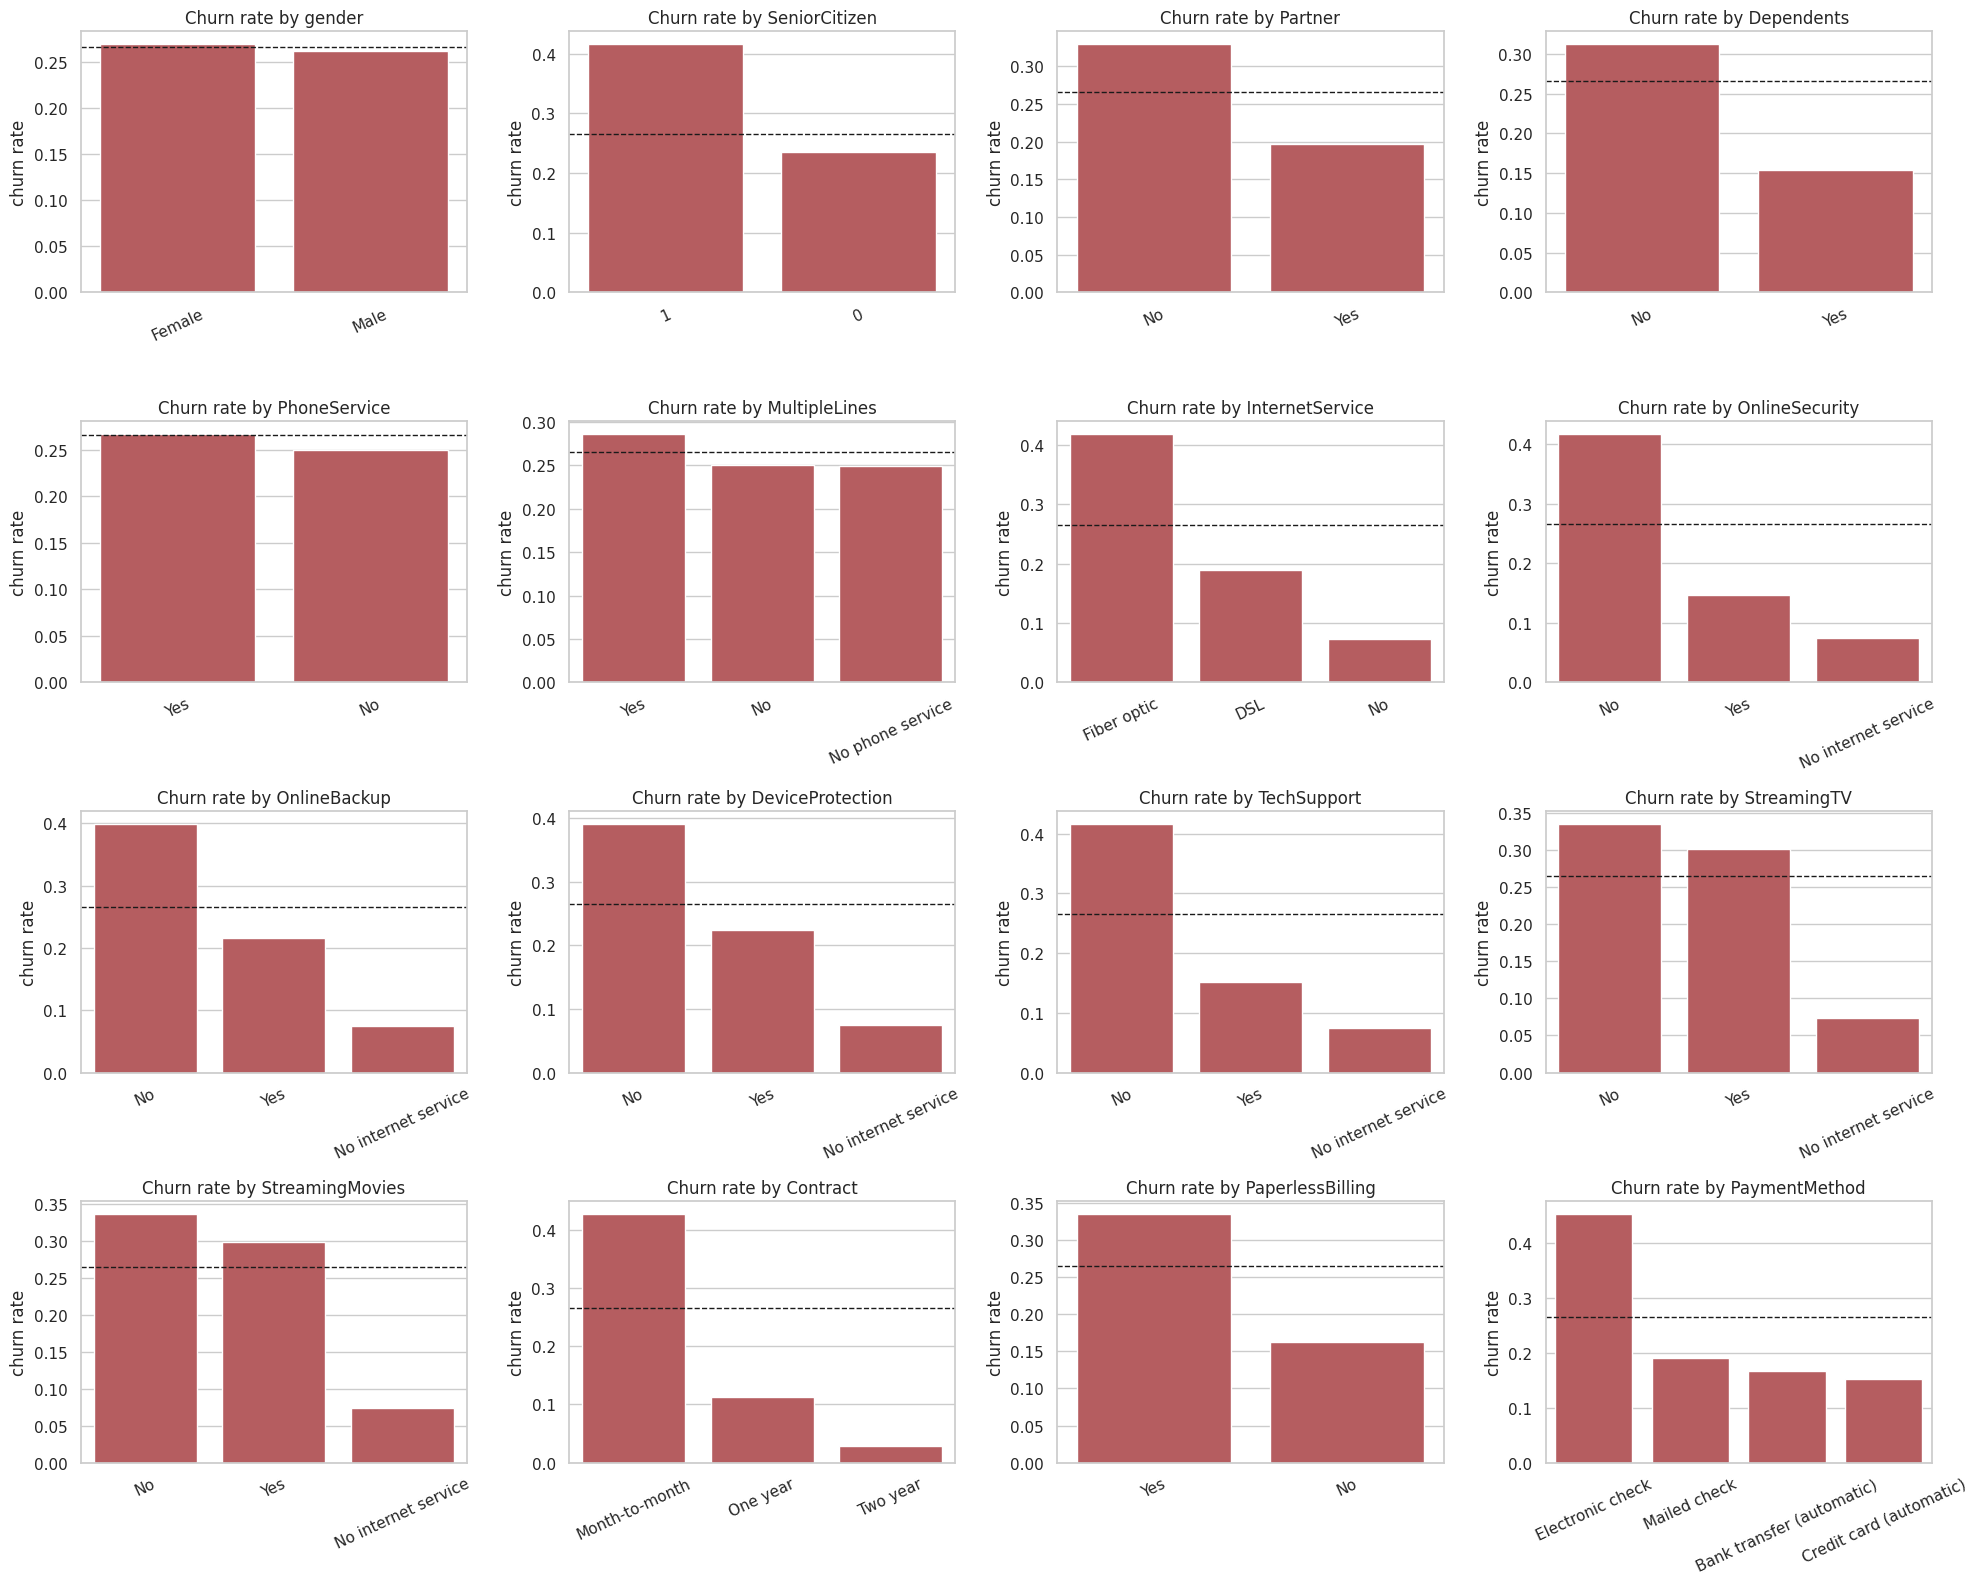

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, c in zip(axes.ravel(), cat_cols):
    rate = df.groupby(c)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color="#C44E52")
    ax.axhline(df["Churn"].mean(), ls="--", c="k", lw=1); ax.set_title(f"Churn rate by {c}"); ax.set_xlabel(""); ax.set_ylabel("churn rate"); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

**Findings** (dashed line = overall churn rate)
- **Contract type is the strongest signal:** month-to-month customers churn far more than one/two-year contract customers.
- **Tenure:** churners are mostly new customers (low median tenure).
- **Internet service:** fiber-optic customers churn more than DSL or no-internet customers; they also pay more per month.
- **Payment method:** electronic-check payers churn noticeably more.
- Customers **without** Online Security / Tech Support churn more; `gender` and `PhoneService` barely matter.
- Senior citizens, customers without partners/dependents, and paperless-billing customers show moderately higher churn.

### 2.5 Correlation analysis

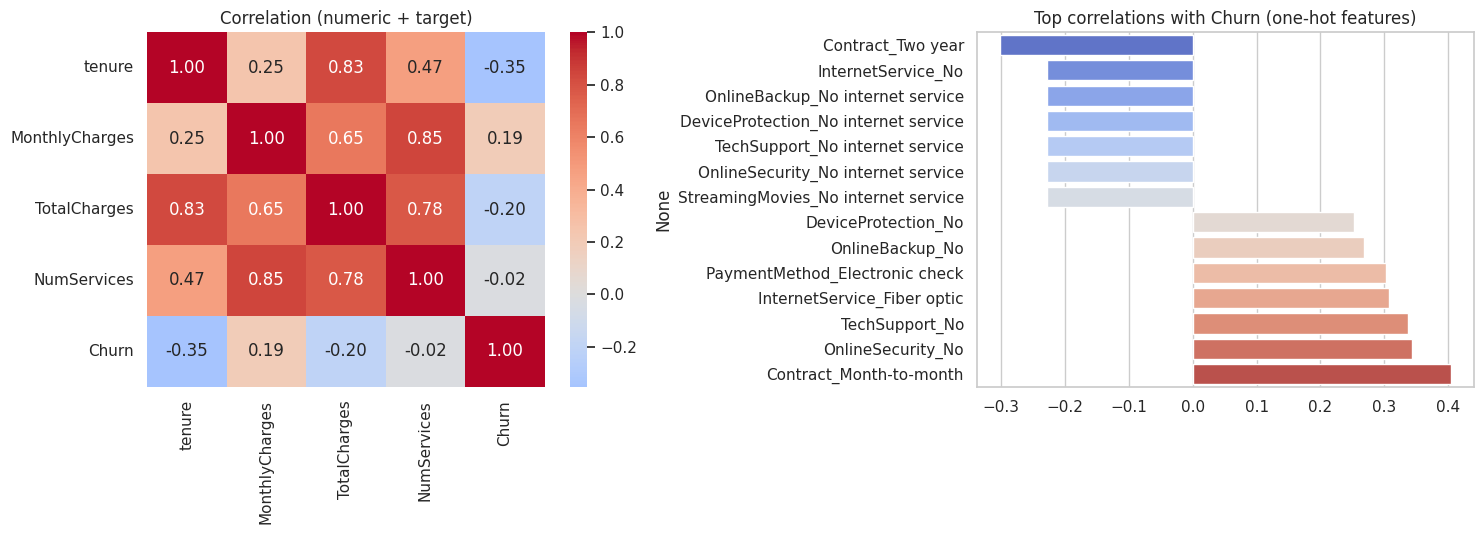

In [12]:
corr_df = df[num_cols + ["Churn"]]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0]); ax[0].set_title("Correlation (numeric + target)")
enc = pd.get_dummies(df.drop(columns=num_cols)).astype(float)
corr_target = enc.corr()["Churn"].drop("Churn").sort_values()
top = pd.concat([corr_target.head(7), corr_target.tail(7)])
sns.barplot(x=top.values, y=top.index, ax=ax[1], palette="coolwarm"); ax[1].set_title("Top correlations with Churn (one-hot features)")
plt.tight_layout(); plt.show()

**Findings**
- `tenure` and `TotalCharges` are strongly correlated (0.83), and `TotalCharges` is largely `tenure × MonthlyCharges`; `NumServices` also tracks `MonthlyCharges` (0.85). This **multicollinearity** can destabilise Logistic Regression coefficients (regularisation helps) but doesn't hurt tree models.
- Strongest negative correlates of churn: long tenure, two-year contract, no internet service. Strongest positive: month-to-month contract, fiber optic, electronic check. (Several "No internet service" bars are the same underlying group repeated across add-on columns.)

## 3. Train/Test Split & Preprocessing Pipeline
**Split first, preprocess second.** A stratified 80/20 split keeps the churn ratio equal in both sets. Everything learned from data (medians, outlier fences, scaling, one-hot categories) is fitted on the training portion only.

| Step | Applied to | Why |
|---|---|---|
| `SimpleImputer(median)` | numeric | Median is robust to skew; fills the 11 blank `TotalCharges` |
| `Winsorizer` (IQR fences) | numeric | Caps outliers instead of deleting rows |
| `StandardScaler` | numeric | Required for Logistic Regression; harmless for trees |
| `OneHotEncoder(handle_unknown='ignore')` | categorical | Nominal categories with no order; `ignore` makes inference robust to unseen values |

In [13]:
X = df[RAW_FEATURES + ["NumServices"]]; y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train {X_train.shape} | Test {X_test.shape}")
print("Churn rate  train: %.3f  test: %.3f" % (y_train.mean(), y_test.mean()))

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("cap", Winsorizer(k=1.5)), ("scale", StandardScaler())])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CATEGORICAL_FEATURES),
])

Train (5634, 20) | Test (1409, 20)
Churn rate  train: 0.265  test: 0.265


## 4. Model Training & Comparison
Four algorithms of increasing complexity are compared with **5-fold stratified cross-validation on the training set** (the test set stays untouched):

1. **Logistic Regression** — interpretable linear baseline.
2. **Decision Tree** (depth-limited) — simple non-linear, interpretable model; shows the overfitting/variance trade-off.
3. **Random Forest** — bagged trees; reduces variance, handles interactions.
4. **Gradient Boosting** — sequential trees; typically strongest on tabular data.

`class_weight='balanced'` is used where supported to handle the 73/27 imbalance.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({"Model": name, **{k: res[f"test_{k}"].mean() for k in scoring}})
cv_results = pd.DataFrame(rows).set_index("Model").round(4)
cv_results

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.7490,0.5176,0.8013,0.6287,0.8460
Decision Tree,0.7419,0.5095,0.7773,0.6150,0.8280
Random Forest,0.7756,0.5589,0.7304,0.6330,0.8448
Gradient Boosting,0.8019,0.6575,0.5304,0.5869,0.8479


The comparison above is **cross-validated on training data only**. Because the preprocessing lives inside the pipeline, each fold re-fits its own imputer/scaler/encoder, so there is no leakage between folds.

### 4.1 Hyper-parameter tuning
The two strongest candidates (Random Forest and Gradient Boosting) get a small `GridSearchCV` optimising **ROC-AUC**, which is threshold-independent and appropriate for imbalanced data.

In [15]:
grids = {
    "Random Forest": (RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
                      {"clf__n_estimators": [200, 400], "clf__max_depth": [6, 10, None], "clf__min_samples_leaf": [3, 8]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE),
                          {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.05, 0.1], "clf__max_depth": [2, 3]}),
}
tuned = {}
for name, (clf, grid) in grids.items():
    gs = GridSearchCV(Pipeline([("prep", preprocessor), ("clf", clf)]), grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    print(f"{name}: best CV ROC-AUC = {gs.best_score_:.4f} | params = {gs.best_params_}")

Random Forest: best CV ROC-AUC = 0.8471 | params = {'clf__max_depth': 10, 'clf__min_samples_leaf': 8, 'clf__n_estimators': 400}


Gradient Boosting: best CV ROC-AUC = 0.8499 | params = {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}


## 5. Final Evaluation on the Held-Out Test Set
Untuned Logistic Regression and Decision Tree are refit on the training set; the tuned Random Forest and Gradient Boosting come from the grid search. All are scored once on the untouched test set.

In [16]:
final = {
    "Logistic Regression": Pipeline([("prep", preprocessor), ("clf", models["Logistic Regression"])]).fit(X_train, y_train),
    "Decision Tree": Pipeline([("prep", preprocessor), ("clf", models["Decision Tree"])]).fit(X_train, y_train),
    "Random Forest (tuned)": tuned["Random Forest"],
    "Gradient Boosting (tuned)": tuned["Gradient Boosting"],
}
rows = []
for name, m in final.items():
    pred, proba = m.predict(X_test), m.predict_proba(X_test)[:, 1]
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba)})
test_results = pd.DataFrame(rows).set_index("Model").round(4)
test_results.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting (tuned),0.7999,0.6586,0.5107,0.5753,0.8454
Random Forest (tuned),0.7700,0.5473,0.7727,0.6408,0.8434
Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8414
Decision Tree,0.7551,0.5269,0.7594,0.6221,0.8330


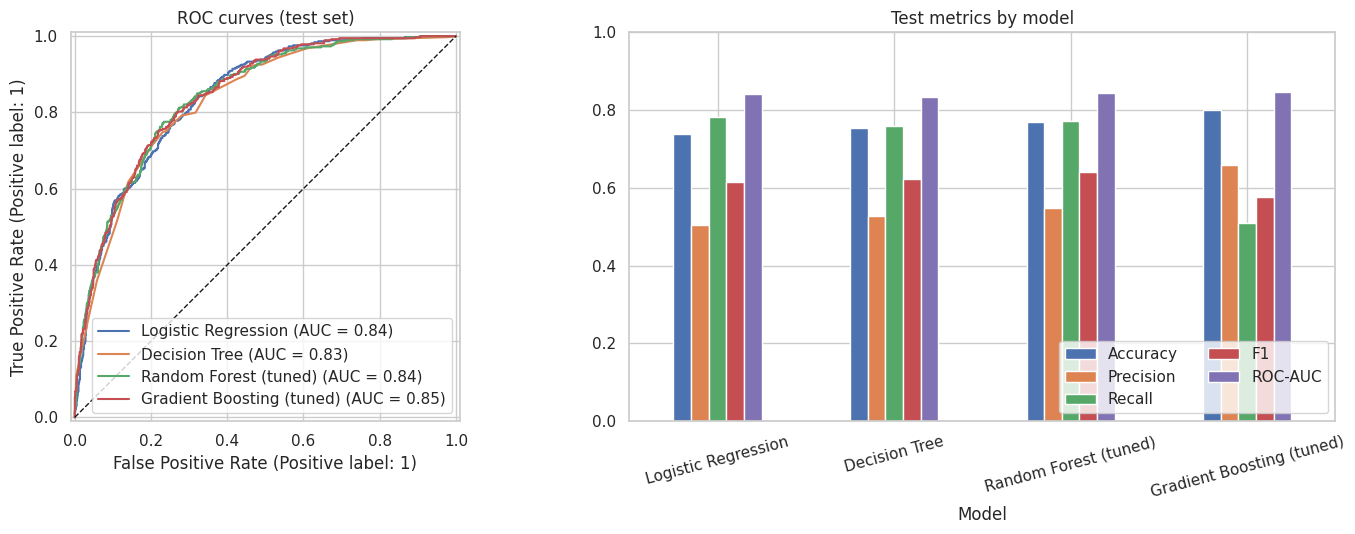

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for name, m in final.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, name=name, ax=ax[0])
ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_title("ROC curves (test set)")
test_results[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot.bar(ax=ax[1], rot=15); ax[1].set_title("Test metrics by model"); ax[1].set_ylim(0, 1); ax[1].legend(loc="lower right", ncol=2)
plt.tight_layout(); plt.show()

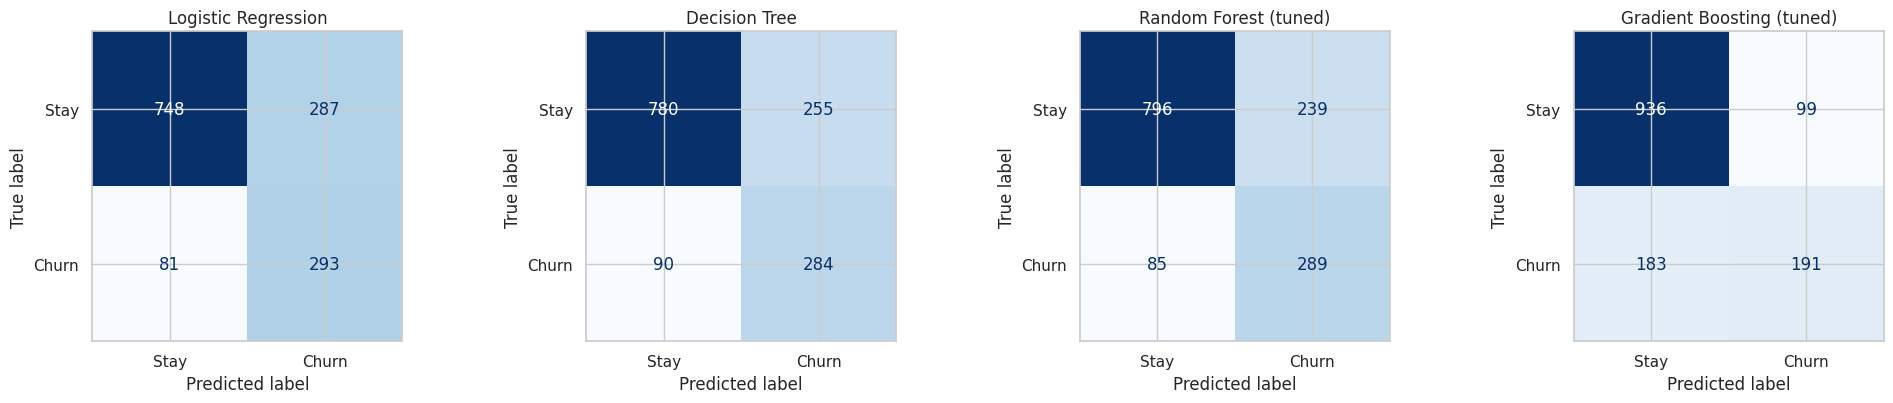

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, (name, m) in zip(axes, final.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, display_labels=["Stay", "Churn"], cmap="Blues", colorbar=False, ax=ax); ax.set_title(name)
plt.tight_layout(); plt.show()

## 6. Choosing and Saving the Final Model

In [19]:
best_name = test_results["ROC-AUC"].idxmax()
best_model = final[best_name]
print("Selected model:", best_name)
print(classification_report(y_test, best_model.predict(X_test), target_names=["Stay", "Churn"]))

Selected model: Gradient Boosting (tuned)
              precision    recall  f1-score   support

        Stay       0.84      0.90      0.87      1035
       Churn       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### 6.1 Decision-threshold tuning
The default 0.5 cut-off favours the majority class: the tuned Gradient Boosting model catches only about half of churners. In retention campaigns a missed churner usually costs more than a wasted discount, so I pick the threshold that **maximises F1 on out-of-fold training predictions** (`cross_val_predict`), so the test set is not used to choose it, and then report the test result once.

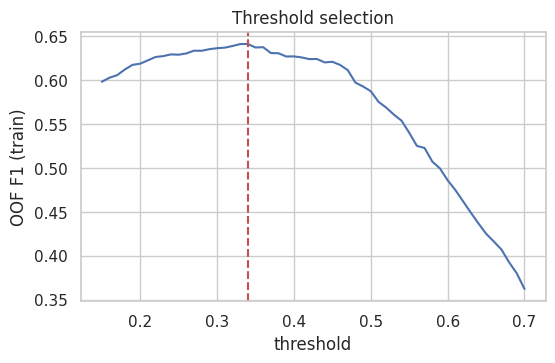

Chosen threshold: 0.34


,Accuracy,Precision,Recall,F1
Default 0.50,0.7999,0.6586,0.5107,0.5753
Tuned 0.34,0.7779,0.5634,0.7246,0.6339


In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
oof = cross_val_predict(clone(best_model), X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
grid_t = np.arange(0.15, 0.71, 0.01)
f1s = [f1_score(y_train, oof >= t) for t in grid_t]
THRESHOLD = float(grid_t[int(np.argmax(f1s))])
proba_test = best_model.predict_proba(X_test)[:, 1]
cmp = pd.DataFrame({t: {"Accuracy": accuracy_score(y_test, proba_test >= v), "Precision": precision_score(y_test, proba_test >= v),
                        "Recall": recall_score(y_test, proba_test >= v), "F1": f1_score(y_test, proba_test >= v)}
                    for t, v in {"Default 0.50": 0.5, f"Tuned {THRESHOLD:.2f}": THRESHOLD}.items()}).T.round(4)
plt.figure(figsize=(6, 3.5)); plt.plot(grid_t, f1s); plt.axvline(THRESHOLD, c="r", ls="--"); plt.xlabel("threshold"); plt.ylabel("OOF F1 (train)"); plt.title("Threshold selection"); plt.show()
print("Chosen threshold:", round(THRESHOLD, 2)); cmp

### 6.2 Which features drive the prediction?

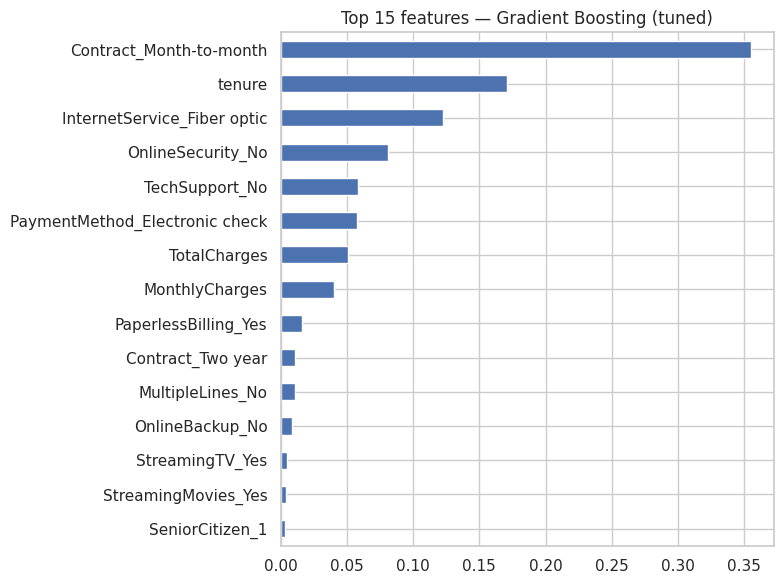

In [21]:
prep = best_model.named_steps["prep"]; clf = best_model.named_steps["clf"]
names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=names)
else:
    imp = pd.Series(clf.coef_[0], index=names)
imp = imp.reindex(imp.abs().sort_values(ascending=False).index).head(15)[::-1]
imp.plot.barh(figsize=(8, 6), color="#4C72B0"); plt.title(f"Top 15 features — {best_name}"); plt.tight_layout(); plt.show()

In [22]:
# Persist the whole pipeline (preprocessing + model) so inference applies the exact same transformations.
joblib.dump(best_model, "models/churn_model.joblib")
joblib.dump({"model_name": best_name, "metrics": test_results.loc[best_name].to_dict(),
             "all_metrics": test_results.reset_index().to_dict("records"),
             "threshold": THRESHOLD, "metrics_at_threshold": cmp.iloc[1].to_dict(), "train_medians": X_train[["tenure", "MonthlyCharges"]].median().to_dict()}, "models/model_card.joblib")
# Sanity check: reload and verify identical predictions
reloaded = joblib.load("models/churn_model.joblib")
assert np.allclose(reloaded.predict_proba(X_test), best_model.predict_proba(X_test)); print("Saved & verified models/churn_model.joblib")

Saved & verified models/churn_model.joblib


## 7. Conclusions
**Model comparison (held-out test set, 1,409 customers, default 0.5 threshold)**

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Gradient Boosting (tuned) | 0.800 | 0.659 | 0.511 | 0.575 | **0.845** |
| Random Forest (tuned) | 0.770 | 0.547 | 0.773 | 0.641 | 0.843 |
| Logistic Regression | 0.739 | 0.505 | 0.783 | 0.614 | 0.841 |
| Decision Tree | 0.755 | 0.527 | 0.759 | 0.622 | 0.833 |

**Key takeaways**
1. **Ranking quality is nearly identical across models (ROC-AUC 0.83-0.845).** Logistic Regression is within ~0.004 of Gradient Boosting, so the signal here is largely simple and linear; extra model complexity buys very little.
2. **Gradient Boosting was selected** for the best ROC-AUC (and well-ranked probabilities for the app). At 0.5 it recalls only ~51% of churners, so I tuned the threshold to **0.34** using out-of-fold *training* predictions. On the test set this raises **recall from 0.51 to 0.72** and **F1 from 0.58 to 0.63**, at the cost of accuracy (0.80 → 0.78) and precision (0.66 → 0.56). That is the right trade-off when a missed churner costs more than an unnecessary retention offer.
3. **Honest caveat:** the tuned Random Forest reaches a similar F1 (0.64) with no threshold tuning, and differences between models of this size are within the noise of a 1,409-row test set. Gradient Boosting is a reasonable, not a decisive, choice.
4. **Main churn drivers:** month-to-month contracts (by far the top feature), short tenure, fiber-optic internet, no online security / tech support, and electronic-check payment.
5. **Business suggestion:** target new, month-to-month, fiber-optic customers with incentives to move to annual contracts and bundle security / support services.

**Limitations & next steps**
- Single snapshot dataset with no temporal validation; a real deployment should be validated on later time periods.
- Precision of ~0.56 means roughly 4 in 10 flagged customers would not have churned. A cost-sensitive threshold based on real retention cost vs. customer lifetime value would beat an F1-based one.
- Further work: probability calibration, SHAP explanations, XGBoost/LightGBM, and resampling (SMOTE) comparisons.